# Regression Task on Taiwan Air Quality Index Dataset

Link to Dataset: https://www.kaggle.com/datasets/taweilo/taiwan-air-quality-data-20162024

## 0 Imports

In [4]:
#%pip install kagglehub

In [5]:
# Standard Libraries
import pandas as pd
import numpy as np
import os
import kagglehub
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn
from sklearn.impute import KNNImputer
# Config Files and Python Modules

## 1 Load and Explore Dataset

### 1.1 Load Raw Data

In [6]:
data_root = os.path.abspath("../data")
os.makedirs(data_root, exist_ok=True)
local_csv = os.path.join(data_root, "air_quality.csv")

def _find_csv(directory):
    for root, _, files in os.walk(directory):
        for f in files:
            if f.lower().endswith('.csv'):
                return os.path.join(root, f)
    return None

if not os.path.isfile(local_csv):
    print("Downloading Taiwan Air Quality Data from Kaggle...")
    download_path = kagglehub.dataset_download("taweilo/taiwan-air-quality-data-20162024")
    csv_path = None
    if os.path.isdir(download_path):
        csv_path = _find_csv(download_path)
    elif zipfile.is_zipfile(download_path):
        with zipfile.ZipFile(download_path) as archive:
            archive.extractall(data_root)
        csv_path = _find_csv(data_root)
        os.remove(download_path)
    else:
        csv_path = download_path
    if csv_path is None or not os.path.isfile(csv_path):
        raise FileNotFoundError("Could not locate air_quality csv after download.")
    if os.path.abspath(csv_path) != os.path.abspath(local_csv):
        os.replace(csv_path, local_csv)

print("Reading Taiwan Air Quality Data...")
data = pd.read_csv(local_csv, encoding="latin1", on_bad_lines='skip', engine='python')
#print name of all columns



Reading Taiwan Air Quality Data...


### 1.2 Initial Data Overview

In [7]:
#check for duplicates
print(f"Number of duplicate rows: {data.duplicated().sum()}")



#split into features and target
X = data.drop(columns=['date', 'sitename', 'county', 'aqi', 'pollutant' , 'status', 'unit', 'longitude', 'latitude', 'siteid'])
y = data['aqi']

#convert all columns to numeric, coerce errors to NaN
X = X.apply(pd.to_numeric, errors='coerce')
Y= y.apply(pd.to_numeric, errors='coerce')

#exclude y NaN values from X and Y
valid_indices = Y.notnull()
X = X[valid_indices]
Y = Y[valid_indices]

Number of duplicate rows: 0


### 1.3 Exploratory Data Analysis if interesting

In [8]:
# Display basic information about the dataset
# print(data.info())
# print(data.head())
# print(data.describe())


#### 1.3.1 Histograms

#### 1.3.2 Correlations

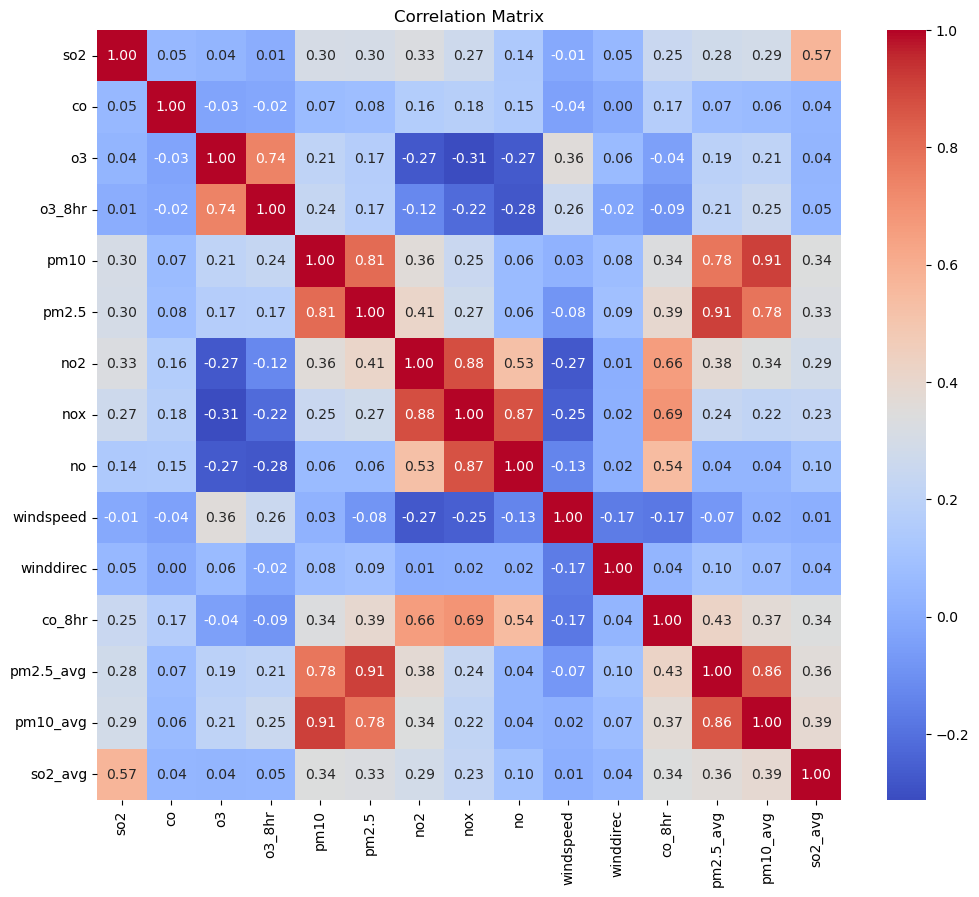

In [9]:
# correlation matrix


plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### 1.3.3 Visualizations

In [ ]:
#print statistics of each feature
print(X.describe())
print(Y.describe())

                so2            co            o3        o3_8hr          pm10  \
count  5.720319e+06  5.705892e+06  5.654626e+06  5.713535e+06  5.717758e+06   
mean   1.992542e+00  3.385905e-01  3.041863e+01  3.035164e+01  3.438834e+01   
std    1.875875e+00  1.209309e+00  1.835725e+01  1.585386e+01  2.429178e+01   
min   -9.990000e+02 -9.990000e+02 -9.990000e+02 -1.000000e+00 -9.990000e+02   
25%    1.000000e+00  1.900000e-01  1.600000e+01  1.800000e+01  1.800000e+01   
50%    1.600000e+00  2.900000e-01  2.820000e+01  2.900000e+01  2.800000e+01   
75%    2.500000e+00  4.100000e-01  4.200000e+01  4.100000e+01  4.500000e+01   
max    2.554000e+02  3.858000e+01  4.100000e+02  1.358000e+02  1.407000e+03   

              pm2.5           no2           nox            no     windspeed  \
count  5.663366e+06  5.694510e+06  5.693934e+06  5.693598e+06  5.559236e+06   
mean   1.684841e+01  1.125169e+01  1.471646e+01  3.449846e+00  2.212753e+00   
std    1.271172e+01  8.677392e+00  1.488188e+01  8.

## 2 Data Cleaning and Preprocessing

### 2.1 Missing Values

In [ ]:
#missing values
print("Missing values in each column:")
print(X.isnull().sum())
print("Missing values in target variable:")
print(Y.isnull().sum())


Missing values in each column:
so2          118869
co           133296
o3           184562
o3_8hr       125653
pm10         121430
pm2.5        175822
no2          144678
nox          145254
no           145590
windspeed    279952
winddirec    280206
co_8hr        78214
pm2.5_avg     46833
pm10_avg      62838
so2_avg      603527
dtype: int64
Missing values in target variable:
0
5839188


### 2.2 Train/Test Split

In [12]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

### 2.3 Scaling and Encoding Pipelines

not sure if scaling is needed will be implemented in the pipeline later on


## 3 Train and Evaluate Baseline Models (sklearn)


### 3.1 Define Model Pipelines


In [ ]:
#define a pipeline with knn imputer and standard scaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#fit and transform the training data, transform the test data
X_train = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

#print the shape of the training and test data
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of test data: {X_test.shape}")
print(X_train.describe())
#print missing values in training and test data
print("__________________________")
print("Missing values in training and test data after imputation:")
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Shape of training data: (4671350, 15)
Shape of test data: (1167838, 15)
                so2            co            o3        o3_8hr          pm10  \
count  4.671350e+06  4.671350e+06  4.671350e+06  4.671350e+06  4.671350e+06   
mean   2.303699e-16  1.471851e-16 -5.977451e-16 -1.567549e-16 -7.087813e-16   
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
min   -3.564191e+00 -9.403368e+02 -5.698060e+01 -1.998922e+00 -4.300354e+01   
25%   -5.807717e-01 -1.306076e-01 -7.758869e-01 -7.875847e-01 -6.820902e-01   
50%   -1.712828e-01 -4.592126e-02 -7.844816e-02 -8.628438e-02 -2.243360e-01   
75%    2.967046e-01  6.699382e-02  6.134554e-01  6.150160e-01  4.414882e-01   
max    1.482392e+02  3.593635e+01  7.449462e+00  6.722704e+00  5.711977e+01   

              pm2.5           no2           nox            no     windspeed  \
count  4.671350e+06  4.671350e+06  4.671350e+06  4.671350e+06  4.671350e+06   
mean   9.212745e-16 -9.399817e-16 -8.946601e-16 -1.492834e

### 3.2 Cross-Validation Setup


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from config import (BASELINE_MODELS, PARAM_DISTS, SCORING_METRICS,
                    RANDOM_SEED, CV_FOLDS)

results = {}
for name, estimator in BASELINE_MODELS.items():
    if name not in PARAM_DISTS:
        # grid/random search not defined for this model
        continue
    print(f'Running RandomizedSearchCV for {name}...')
    pipeline = Pipeline([('model', estimator)])
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=PARAM_DISTS[name],
        scoring=SCORING_METRICS,
        refit='rmse',
        n_iter=40,
        cv=CV_FOLDS,
        verbose=2,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    results[name] = search
    print(f'Best RMSE (negated) for {name}: {search.best_score_:.4f}')
    print('Best params:', search.best_params_)

# Access results dict for later inspection, e.g., results['random_forest'].cv_results_


Running RandomizedSearchCV for linear...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\JakobOlsacher\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=40. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best RMSE (negated) for linear: -7.8036
Best params: {'model__positive': False, 'model__fit_intercept': True}
Running RandomizedSearchCV for decision_tree...
Fitting 3 folds for each of 40 candidates, totalling 120 fits


### 3.3 Hyperparameter Grid Search


### 3.4 Baseline Model Evaluation

## 4 Train and Evaluate Custom Implementations
### 4.1 Custom Regression Tree
### 4.2 Custom Random Forest
### 4.3 Comparison: sklearn vs Custom Implementations

## 5 Results and Discussion

### 5.1 Results Summary
### 5.2 Discussion and Insights